In [7]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp

In [8]:
import os
print(os.getcwd())

C:\Users\Cheng\OneDrive\Documents\Github\VarianceArithmetic\IPyNb


In [12]:
df = pd.read_csv("../Python/Output/NormalMomentum_5_var.txt", sep='\t')
df.head()

,Order,Value,Uncertainty
0,0,0.999999,9.280575e-17
1,1,0.000000,4.940656e-324
2,2,0.999985,9.280575e-17
3,3,0.000000,4.940656e-324
4,4,2.999582,2.661649e-16


In [13]:
df = df[(df['Order'] % 2) == 0]

In [15]:
df['Normal Asymptote'] = 2*sp.stats.norm.pdf(5) *5.0**(df["Order"] + 1)/(df["Order"] + 1)
df['Asymptote/Momentum Ratio'] = df['Normal Asymptote'] / df['Value']
df['Normal Moment'] = df['Value']
df['Uniform Moment'] = (math.sqrt(3) ** df["Order"]*2)/(df["Order"]*2 + 1)

<AxesSubplot:title={'center':'Normal Moment $\\zeta(2n, 5)$ vs Asymptotic $2N(5) \\frac{5^{2N + 1}}{2N + 1}$'}, xlabel='Order'>

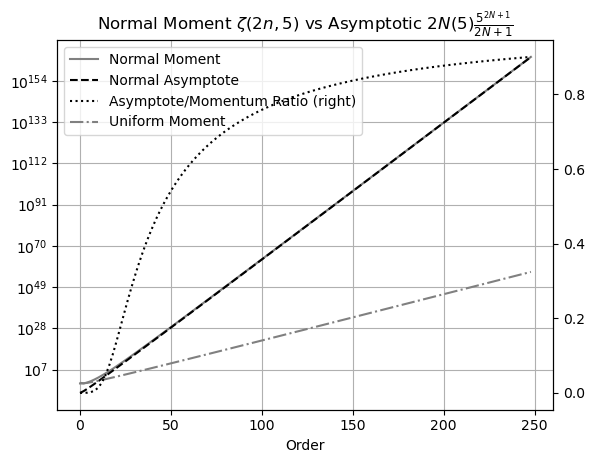

In [16]:
ax = df.plot(x='Order', y='Normal Moment', c='gray', ls='-')
df.plot(ax=ax, x='Order', y='Normal Asymptote', style='k--')
ax2 = df.plot(ax=ax, x='Order', y='Asymptote/Momentum Ratio', secondary_y=True, style='k:')
df.plot(ax=ax, x='Order', y='Uniform Moment', c='gray', ls='-.', grid=True, logy=True,
        title=r'Normal Moment $\zeta(2n, 5)$ vs Asymptotic $2N(5) \frac{5^{2N + 1}}{2N + 1}$')